# Variational Autoencoder (VAE) on Fashion-MNIST

A convolutional VAE trained on Fashion-MNIST to learn a structured latent space.

**What this notebook covers:**
1. CNN-based Encoder / Decoder architecture
2. VAE loss (Reconstruction + KL Divergence)
3. Image reconstruction quality
4. Latent space interpolation between two images
5. Random image generation by sampling from the prior
6. t-SNE visualization of the latent space (colored by class)

## 1. Setup & Imports

In [30]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# ── Reproducibility ──────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## 2. Dataset

In [31]:
BATCH_SIZE = 128

transform = transforms.Compose([
    transforms.ToTensor(),   # → [0, 1]
])

train_dataset = datasets.FashionMNIST(root="./data", train=True,  download=True, transform=transform)
test_dataset  = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print(f"Train samples : {len(train_dataset):,}")
print(f"Test  samples : {len(test_dataset):,}")

Train samples : 60,000
Test  samples : 10,000


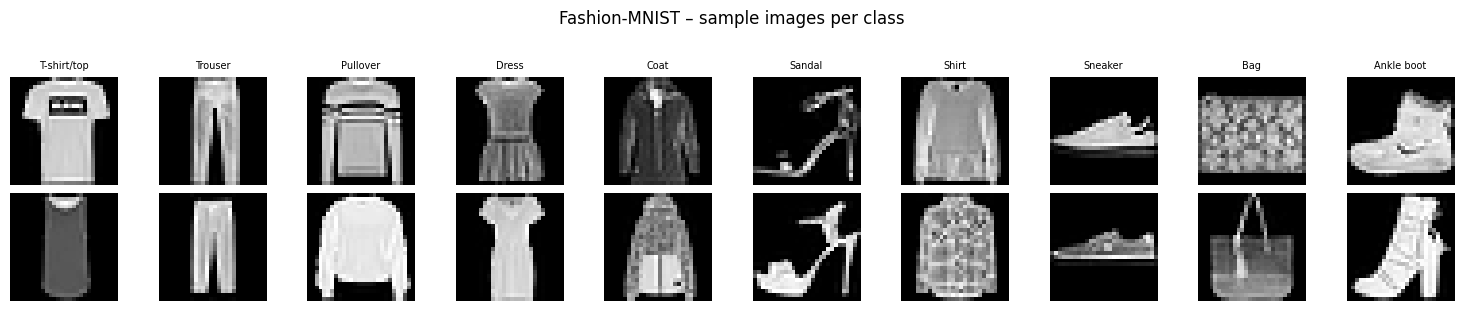

In [32]:
# ── Quick look at the data ────────────────────────────────────────
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for cls in range(10):
    idx = next(i for i, (_, l) in enumerate(train_dataset) if l == cls)
    img, _ = train_dataset[idx]
    axes[0, cls].imshow(img.squeeze(), cmap="gray")
    axes[0, cls].set_title(CLASS_NAMES[cls], fontsize=7)
    axes[0, cls].axis("off")

    idx2 = next(i for i, (_, l) in enumerate(train_dataset) if l == cls and i != idx)
    img2, _ = train_dataset[idx2]
    axes[1, cls].imshow(img2.squeeze(), cmap="gray")
    axes[1, cls].axis("off")

plt.suptitle("Fashion-MNIST – sample images per class", y=1.02)
plt.tight_layout()
plt.show()

## 3. Model Architecture

```
Input (1×28×28)
     │
  Encoder (Conv2d blocks)
     │
  ┌──┴──┐
 μ(z)  σ(z)   ← two parallel linear heads
  └──┬──┘
  Reparameterisation trick: z = μ + ε·σ,  ε ~ N(0,I)
     │
  Decoder (ConvTranspose2d blocks)
     │
Output (1×28×28)
```

**Loss:**  `L = BCE(x̂, x) + β · KL(q(z|x) ∥ p(z))`

where `KL = -½ Σ (1 + log σ² - μ² - σ²)`

In [33]:
class Encoder(nn.Module):
    """Conv2d stack → (mu, log_var)"""

    def __init__(self, latent_dim: int):
        super().__init__()
        # 1×28×28 → 32×14×14 → 64×7×7 → 128×4×4  (3 strided conv blocks)
        self.conv = nn.Sequential(
            nn.Conv2d(1,   32,  kernel_size=3, stride=2, padding=1),  # 14×14
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32,  64,  kernel_size=3, stride=2, padding=1),  # 7×7
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64,  128, kernel_size=3, stride=2, padding=1),  # 4×4
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
        )
        self.flatten_dim = 128 * 4 * 4   # 2048
        self.fc_mu      = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_log_var = nn.Linear(self.flatten_dim, latent_dim)

    def forward(self, x):
        h = self.conv(x).view(x.size(0), -1)
        return self.fc_mu(h), self.fc_log_var(h)


class Decoder(nn.Module):
    """z → ConvTranspose2d stack → reconstructed image"""

    def __init__(self, latent_dim: int):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 128 * 4 * 4)
        # 128×4×4 → 64×7×7 → 32×14×14 → 1×28×28
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=0),  # 7×7
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(64,  32, kernel_size=4, stride=2, padding=1),  # 14×14
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(32,   1, kernel_size=4, stride=2, padding=1),  # 28×28
            nn.Sigmoid(),
        )

    def forward(self, z):
        h = self.fc(z).view(z.size(0), 128, 4, 4)
        return self.deconv(h)


class VAE(nn.Module):
    def __init__(self, latent_dim: int = 32):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterise(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = self.reparameterise(mu, log_var)
        x_hat = self.decoder(z)
        return x_hat, mu, log_var

    def encode(self, x):
        mu, log_var = self.encoder(x)
        return mu

    def decode(self, z):
        return self.decoder(z)


def vae_loss(x_hat, x, mu, log_var, beta: float = 1.0):
    """
    ELBO loss = Reconstruction (BCE) + β · KL divergence

    Both terms summed over dims and averaged over batch — same scale,
    prevents posterior collapse (KL → 0).
    β < 1 favours sharper reconstructions at cost of slightly less
    regular latent space.
    """
    recon = F.binary_cross_entropy(x_hat, x, reduction="sum") / x.size(0)
    kl    = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / x.size(0)
    return recon + beta * kl, recon, kl


LATENT_DIM = 32
model = VAE(latent_dim=LATENT_DIM).to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")

VAE(
  (encoder): Encoder(
    (conv): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2)
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): LeakyReLU(negative_slope=0.2)
      (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): LeakyReLU(negative_slope=0.2)
    )
    (fc_mu): Linear(in_features=2048, out_features=32, bias=True)
    (fc_log_var): Linear(in_features=2048, out_features=32, bias=True)
  )
  (decoder): Decoder(
    (fc): Linear(in_features=32, out_features=2048, bias=True)
    (deconv): Sequential(
      (0): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=

## 4. Training

In [34]:
EPOCHS        = 50
LR            = 1e-3
BETA_MAX      = 0.5   # β < 1 → more weight on reconstruction → sharper images
ANNEAL_EPOCHS = 10    # linearly ramp β from 0 → BETA_MAX over this many epochs

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)

history = {"train_loss": [], "train_recon": [], "train_kl": [],
           "val_loss":   [], "val_recon":   [], "val_kl":   []}


def run_epoch(loader, train: bool, beta: float):
    model.train() if train else model.eval()
    tot_loss = tot_recon = tot_kl = 0.0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, _ in loader:
            x = x.to(DEVICE)
            x_hat, mu, log_var = model(x)
            loss, recon, kl = vae_loss(x_hat, x, mu, log_var, beta=beta)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            tot_loss  += loss.item()
            tot_recon += recon.item()
            tot_kl    += kl.item()
    n = len(loader)
    return tot_loss / n, tot_recon / n, tot_kl / n


print(f"{'Epoch':>6}  {'Beta':>5}  {'Train Loss':>10}  {'Recon':>8}  {'KL':>8}  {'Val Loss':>10}")
print("-" * 62)

for epoch in range(1, EPOCHS + 1):
    beta = min(BETA_MAX, BETA_MAX * epoch / ANNEAL_EPOCHS)
    tr_l, tr_r, tr_k = run_epoch(train_loader, train=True,  beta=beta)
    va_l, va_r, va_k = run_epoch(test_loader,  train=False, beta=beta)
    scheduler.step()

    for k, v in zip(history, [tr_l, tr_r, tr_k, va_l, va_r, va_k]):
        history[k].append(v)

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:>6}  {beta:>5.2f}  {tr_l:>10.4f}  {tr_r:>8.4f}  {tr_k:>8.4f}  {va_l:>10.4f}")

print("\nTraining complete.")

 Epoch   Beta  Train Loss     Recon        KL    Val Loss
--------------------------------------------------------------
     1   0.05    244.0449  240.2219   76.4610    222.3801
     5   0.25    225.6222  214.4647   44.6301    226.3666
    10   0.50    231.8352  216.9656   29.7391    233.0699
    15   0.50    230.2278  216.1356   28.1843    231.4139
    20   0.50    228.8337  214.9597   27.7481    230.3271
    25   0.50    228.4183  214.6854   27.4657    229.9123
    30   0.50    228.1087  214.4514   27.3147    229.5483
    35   0.50    227.4646  213.8435   27.2424    229.0434
    40   0.50    227.3015  213.7298   27.1434    228.9296
    45   0.50    227.1215  213.6080   27.0270    228.8753
    50   0.50    226.8651  213.3391   27.0519    228.5454

Training complete.


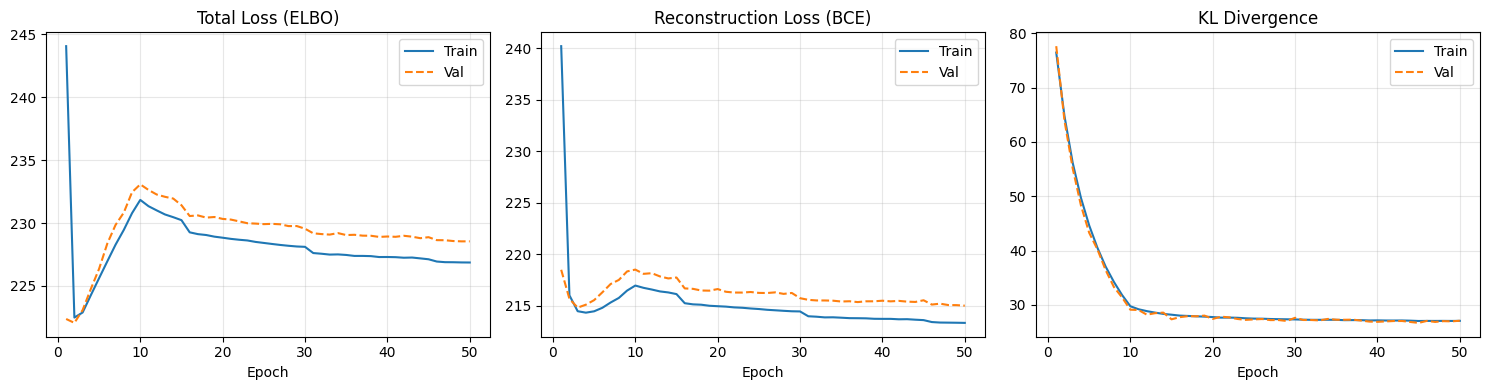

In [35]:
# ── Loss curves ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs = range(1, EPOCHS + 1)

for ax, key, title in zip(
    axes,
    [("train_loss",  "val_loss"),
     ("train_recon", "val_recon"),
     ("train_kl",    "val_kl")],
    ["Total Loss (ELBO)", "Reconstruction Loss (BCE)", "KL Divergence"]
):
    ax.plot(epochs, history[key[0]], label="Train")
    ax.plot(epochs, history[key[1]], label="Val", linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Reconstruction Quality

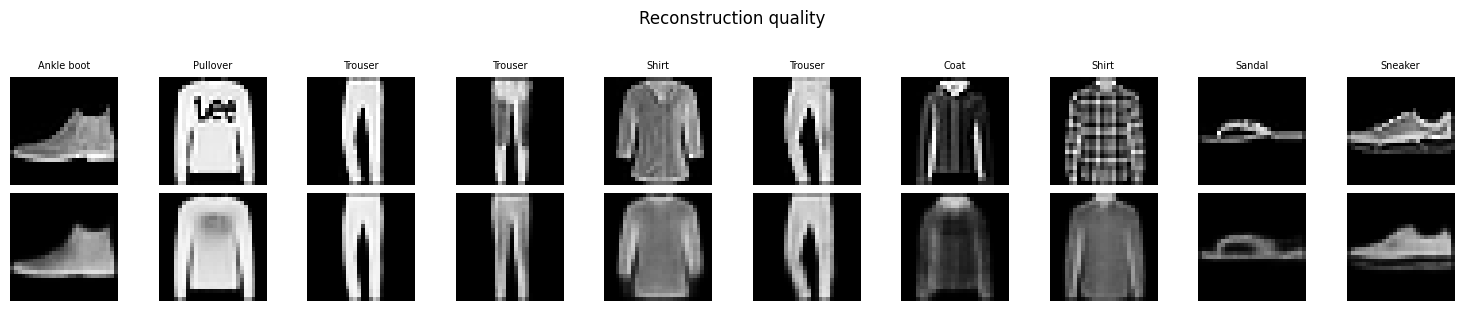

In [36]:
model.eval()
x_batch, labels = next(iter(test_loader))
x_batch = x_batch.to(DEVICE)

with torch.no_grad():
    x_hat, _, _ = model(x_batch)

N = 10
originals    = x_batch[:N].cpu()
reconstructed = x_hat[:N].cpu()

fig, axes = plt.subplots(2, N, figsize=(15, 3))
for i in range(N):
    axes[0, i].imshow(originals[i].squeeze(),     cmap="gray", vmin=0, vmax=1)
    axes[1, i].imshow(reconstructed[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title(CLASS_NAMES[labels[i]], fontsize=7)
    axes[0, i].axis("off")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original",      fontsize=9)
axes[1, 0].set_ylabel("Reconstructed", fontsize=9)
plt.suptitle("Reconstruction quality", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("reconstructions.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Latent Space Interpolation

We pick two images of *different* classes, encode them to get $z_A$ and $z_B$,  
then linearly interpolate: $z(\alpha) = (1-\alpha)\,z_A + \alpha\,z_B$ for $\alpha \in [0,1]$.

A smooth, meaningful transition shows that the VAE has learned a **continuous, well-structured** latent space — something a plain AE typically fails at.

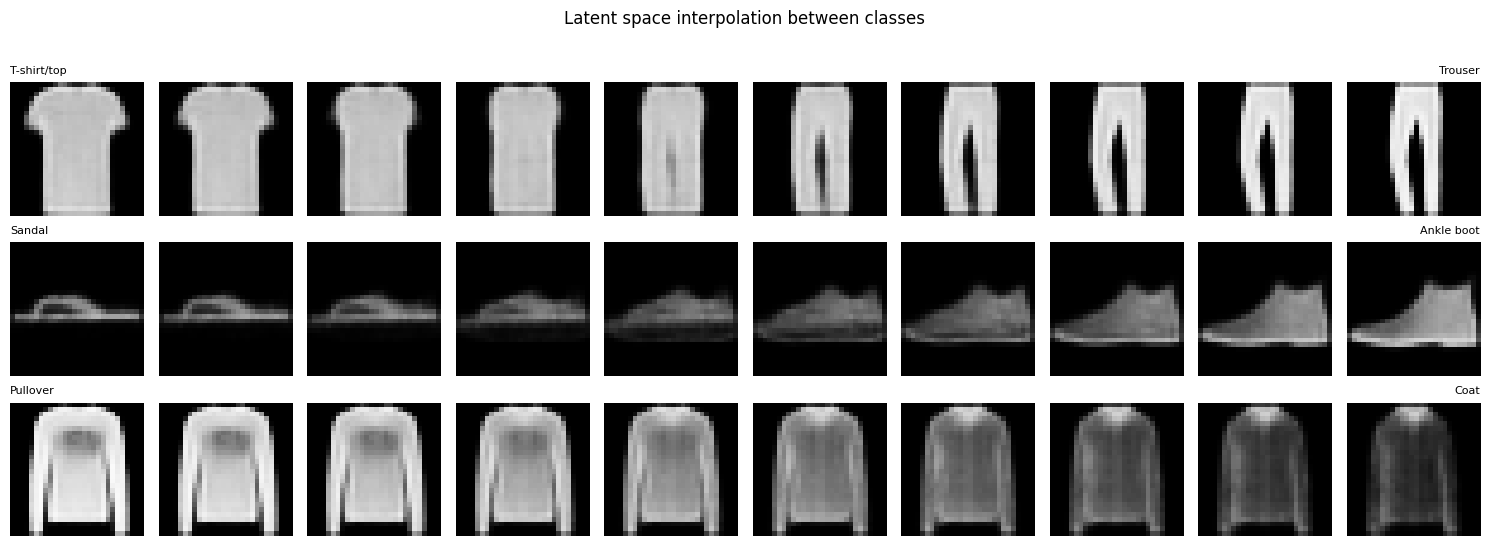

In [37]:
def get_one_sample(dataset, class_idx):
    """Return the first image of the given class as a (1,1,28,28) tensor."""
    for img, label in dataset:
        if label == class_idx:
            return img.unsqueeze(0).to(DEVICE)


STEPS = 10
pairs = [
    (0, 1),   # T-shirt ↔ Trouser
    (5, 9),   # Sandal  ↔ Ankle boot
    (2, 4),   # Pullover ↔ Coat
]

fig, axes = plt.subplots(len(pairs), STEPS, figsize=(15, 1.8 * len(pairs)))
alphas = np.linspace(0, 1, STEPS)

model.eval()
with torch.no_grad():
    for row, (cls_a, cls_b) in enumerate(pairs):
        img_a = get_one_sample(test_dataset, cls_a)
        img_b = get_one_sample(test_dataset, cls_b)
        z_a   = model.encode(img_a)
        z_b   = model.encode(img_b)

        for col, alpha in enumerate(alphas):
            z_interp = (1 - alpha) * z_a + alpha * z_b
            out = model.decode(z_interp).squeeze().cpu().numpy()
            axes[row, col].imshow(out, cmap="gray", vmin=0, vmax=1)
            axes[row, col].axis("off")

        axes[row, 0].set_title(CLASS_NAMES[cls_a], fontsize=8, loc="left")
        axes[row, -1].set_title(CLASS_NAMES[cls_b], fontsize=8, loc="right")

plt.suptitle("Latent space interpolation between classes", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("interpolation.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Random Generation (Sampling from the Prior)

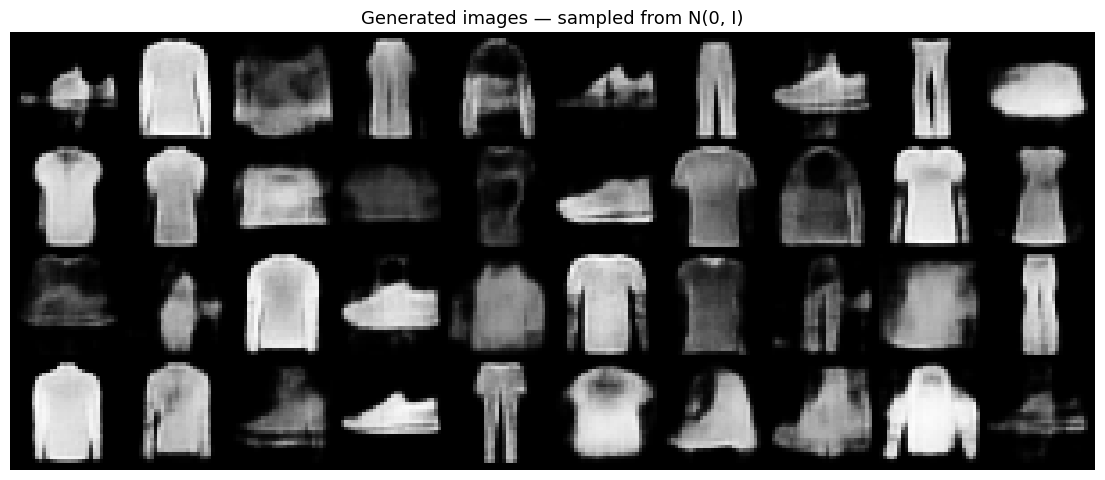

In [38]:
N_GEN = 40

model.eval()
with torch.no_grad():
    z_sample = torch.randn(N_GEN, LATENT_DIM).to(DEVICE)
    generated = model.decode(z_sample).cpu()

grid = make_grid(generated, nrow=10, padding=2, normalize=True)

plt.figure(figsize=(14, 6))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.title("Generated images — sampled from N(0, I)", fontsize=13)
plt.axis("off")
plt.savefig("generated_samples.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. t-SNE Visualization of the Latent Space

We encode the **entire test set**, project the latent codes to 2D with t-SNE,  
and colour each point by its true class label.

Well-separated clusters confirm that the VAE has captured **semantic structure** without any labels during training.

In [39]:
model.eval()
all_z, all_labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        z = model.encode(x.to(DEVICE))
        all_z.append(z.cpu().numpy())
        all_labels.append(y.numpy())

all_z      = np.concatenate(all_z,      axis=0)   # (10000, latent_dim)
all_labels = np.concatenate(all_labels, axis=0)   # (10000,)

print("Running t-SNE … (may take ~60 s on CPU)")
tsne = TSNE(n_components=2, perplexity=40, random_state=SEED, max_iter=1000)
z_2d = tsne.fit_transform(all_z)
print("t-SNE done.")

Running t-SNE … (may take ~60 s on CPU)
t-SNE done.


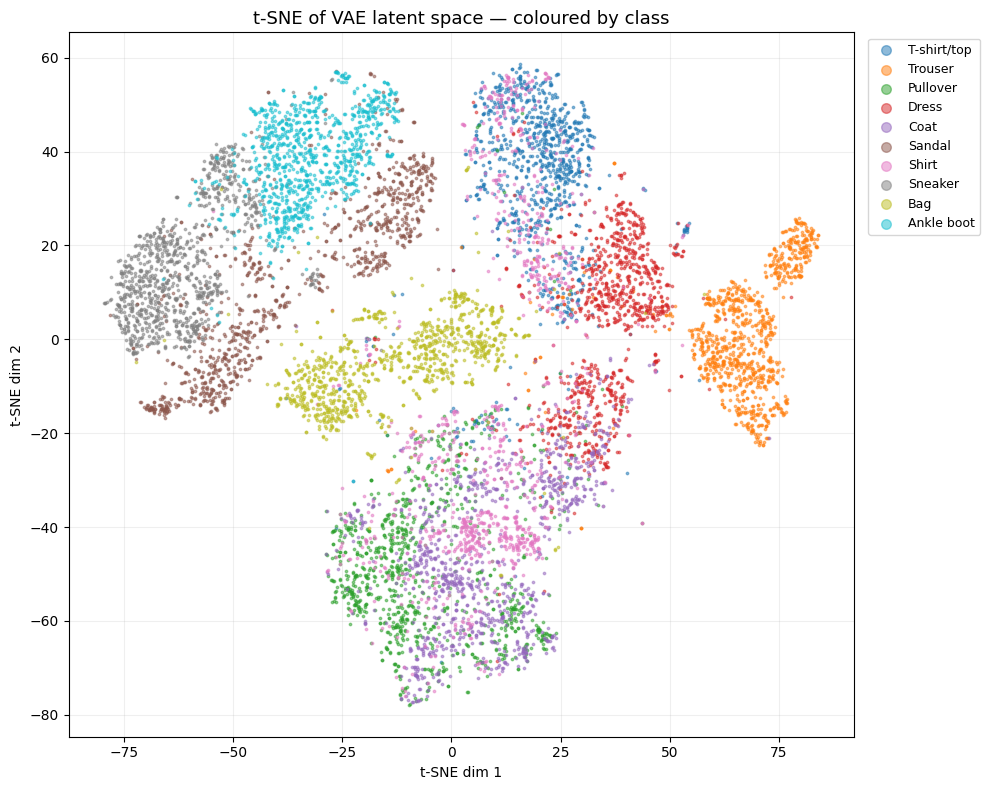

In [40]:
COLORS = plt.colormaps["tab10"]

fig, ax = plt.subplots(figsize=(10, 8))
for cls in range(10):
    mask = all_labels == cls
    ax.scatter(
        z_2d[mask, 0], z_2d[mask, 1],
        s=3, alpha=0.5,
        color=COLORS(cls),
        label=CLASS_NAMES[cls]
    )

ax.legend(markerscale=4, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.set_title("t-SNE of VAE latent space — coloured by class", fontsize=13)
ax.set_xlabel("t-SNE dim 1")
ax.set_ylabel("t-SNE dim 2")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("tsne_latent_space.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Save the Model

In [41]:
torch.save({
    "model_state_dict":     model.state_dict(),
    "latent_dim":           LATENT_DIM,
    "epochs":               EPOCHS,
    "final_val_loss":       history["val_loss"][-1],
    "final_val_recon":      history["val_recon"][-1],
    "final_val_kl":         history["val_kl"][-1],
}, "vae_fashion_mnist.pth")

print("Model saved → vae_fashion_mnist.pth")
print(f"Final val loss  : {history['val_loss'][-1]:.2f}")
print(f"Final val recon : {history['val_recon'][-1]:.2f}")
print(f"Final val KL    : {history['val_kl'][-1]:.2f}")

Model saved → vae_fashion_mnist.pth
Final val loss  : 228.55
Final val recon : 215.01
Final val KL    : 27.07
